# Experiments

Experimentation Notebook

Methodology



# Setup

In [1]:
# Parameters
exp_name = globals().get("exp_name", "MENTAL")
# HEART ok
# ARRHYTHMIA ok
# OBESITY ok
# MENTAL 
# DIABETES 
# AIDS 

In [2]:
import os
# os.environ["OMP_NUM_THREADS"] = "1"
# os.environ["OPENBLAS_NUM_THREADS"] = "1"
# os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
# os.environ["NUMEXPR_NUM_THREADS"] = "1"


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# 1) Standard library
import sys
from pathlib import Path
from functools import reduce
from operator import mul
import logging
import gc

# 2) Paths – expõe ROOT (pasta que contém auxiliar/, fairgbm/, wasserstein_fairness/, etc.)
ROOT = Path.cwd().parent
sys.path[:0] = [
    str(ROOT),                              # para importar auxiliar.*
    str(ROOT / "fairgbm" / "python-package"),      # para importar fairgbm._custom_fairgbm
    str(ROOT / "wasserstein_fairness"),          # para importar wasserstein_fairness._custom_...
]

# 3) Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product

from sklearn.pipeline          import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.model_selection  import train_test_split, RandomizedSearchCV
from sklearn.ensemble         import RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import accuracy_score, classification_report

from aif360.algorithms.preprocessing import DisparateImpactRemover,Reweighing
from aif360.algorithms.inprocessing import GridSearchReduction, PrejudiceRemover

# 4) Seus módulos auxiliares (todos dentro de auxiliar/)
from auxiliar import (
    config,
    experiments_pipeline as exp,
    utils as ut
)
# import prejudice_remover as apr   # se esse .py estiver na raiz de fairnes_treatment

# 5) Seus wrappers custom dentro dos pacotes
from fairgbm._custom_fairgbm                             import FairGBMCustom
from wasserstein_fairness._custom_wesserstein_fairness import WessersteinFairClassifier


c:\Users\gabri\anaconda3\envs\fairness-research\Lib\site-packages\inFairness\utils\ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
c:\Users\gabri\anaconda3\envs\fairness-research\Lib\site-packages\inFairness\utils\ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  mon

## Variables

In [5]:
# General settings
global_seed = config.SEED
all_summary_df = pd.DataFrame()

# Machine Learning settings
split_rate = config.SPLIT_RATE
target_name = config.TARGET_NAME
cross_validation_splits = config.CROSS_VALIDATION_SPLITS


In [6]:
# fairness
exp_config = config.DATASET_CONFIGS[exp_name]
sen_var = exp_config["sen_var"]
fairness_vars = exp_config["fairness_vars"]
dataset_code = exp_config["dataset_code"]

In [7]:
output_dir = ROOT.joinpath("experiments", "results", dataset_code)
output_dir.mkdir(parents=True, exist_ok=True)


## Warnings tretatment

In [8]:
import warnings
from sklearn.exceptions import DataConversionWarning

# 1) DataConversionWarning do sklearn
warnings.filterwarnings("ignore", category=DataConversionWarning)

# 2) Renomeação do force_all_finite 
warnings.filterwarnings(
    "ignore",
    message=".*force_all_finite was renamed to 'ensure_all_finite'.*"
)

# 3) ChainedAssignmentError do Fairlearn (pandas 3.0)
warnings.filterwarnings(
    "ignore",
    message=".*ChainedAssignmentError.*",
    category=FutureWarning,
    module="fairlearn.reductions._moments.utility_parity"
)


## Auxiliar UDF

Salva Resultado a nivel de execução

In [9]:
def create_execution_level_df(folds_results, all_results_df=None):
    # 1) Converte para DataFrame
    folds_results_df = pd.DataFrame(folds_results)

    # 2) Cria ID incremental para repetições implícitas
    folds_results_df["repetition_id"] = (
        folds_results_df
        .groupby(["exp_id", "fold"])
        .cumcount()
    )

    # 3) Define colunas de métricas
    metrics_cols = [c for c in folds_results_df.columns if c not in ('exp_id', 'fold', 'best_params', 'inner_avg_score', 'repetition_id')]

    # 4) Cria um ID único para cada execução: exp_id__repN__foldX__dataset
    folds_results_df["execution_id"] = folds_results_df.apply(
        lambda row: f"{row['exp_id']}__rep{row['repetition_id']}__fold{row['fold']}__{dataset_code}", axis=1
    )

    # 5) Long format
    long_df = folds_results_df.melt(
        id_vars=["exp_id", "fold", "repetition_id", "execution_id"],
        value_vars=metrics_cols,
        var_name="metric",
        value_name="value"
    )

    # 6) Tipo da métrica
    perf = ['accuracy', 'f1', 'precision', 'recall']
    long_df['metric_type'] = np.where(long_df['metric'].isin(perf), 'performance', 'fairness')

    # 7) Adiciona dataset
    long_df['dataset'] = dataset_code
    # 7.1) Adiciona coluna de tipo de experimento
    long_df['exp_type'] = np.where(long_df['exp_id'].str.startswith('B'), 'baseline', 'experiment')
    # 
    # 8) Acumula resultados
    if all_results_df is None:
        all_results_df = long_df.copy()
    else:
        all_results_df = pd.concat([all_results_df, long_df], ignore_index=True)

    return long_df, all_results_df


Visualização de distribuição de folds

In [10]:
def plot_fold_proportions(
    df, fold_index, target_name, sen_var, include_na=False,
    min_label_pct=0.04,     # só anota counts se o segmento ocupar ao menos 4% da barra
    show_totals=True,       # anota "n=..." no topo de cada barra (total do fold)
    fontsize=9
):
    """
    Mostra, por split (train/test), gráficos de barras empilhadas:
      X = folds
      Y = proporção da combinação (sen_var, target_name) em cada fold.
    Anota o valor absoluto (count) de cada segmento dentro da barra.
    """
    data = df.copy()
    if not include_na:
        data = data.dropna(subset=[target_name, sen_var])

    # Combinações fixas para manter colunas consistentes
    targets = sorted(data[target_name].unique())
    sens = sorted(data[sen_var].unique())
    combos = [(s, t) for s in sens for t in targets]
    combo_labels = [f"{sen_var}={s} | y={t}" for (s, t) in combos]
    full_idx = pd.MultiIndex.from_tuples(combos, names=[sen_var, target_name])

    # Coleta contagens e proporções por fold/split
    rows = []
    for i, (tr_idx, te_idx) in enumerate(fold_index):
        for split_name, idx in [('train', tr_idx), ('test', te_idx)]:
            sub = data.iloc[idx]
            counts = (sub.groupby([sen_var, target_name]).size()
                        .reindex(full_idx, fill_value=0))
            total = int(counts.sum())
            pcts = (counts / total) if total > 0 else counts * 0.0

            out = counts.reset_index(name='count')
            out['pct'] = pcts.values
            out['total'] = total
            out['fold'] = i
            out['split'] = split_name
            rows.append(out)

    props = pd.concat(rows, ignore_index=True)
    props['combo'] = props.apply(lambda r: f"{sen_var}={r[sen_var]} | y={r[target_name]}", axis=1)

    # Plot para um split
    def _plot_one(split):
        sub = props[props['split'] == split].copy()
        if sub.empty:
            return

        pivot_pct = (sub.pivot_table(index='fold', columns='combo', values='pct', fill_value=0.0)
                       .reindex(columns=combo_labels, fill_value=0.0)
                       .sort_index())
        pivot_cnt = (sub.pivot_table(index='fold', columns='combo', values='count', fill_value=0)
                       .reindex(columns=combo_labels, fill_value=0)
                       .sort_index())
        totals = pivot_cnt.sum(axis=1)

        x = np.arange(len(pivot_pct.index))
        bottom = np.zeros(len(pivot_pct.index))

        plt.figure(figsize=(10, 4))
        for col in pivot_pct.columns:
            heights = pivot_pct[col].values
            bars = plt.bar(x, heights, bottom=bottom)  # sem cores específicas
            # anota counts no meio de cada segmento
            counts_here = pivot_cnt[col].values
            for xi, h, b, c in zip(x, heights, bottom, counts_here):
                if c > 0 and h >= min_label_pct:
                    plt.text(xi, b + h/2, f"{int(c)}", ha='center', va='center', fontsize=fontsize)
            bottom += heights

        # totais por fold no topo
        if show_totals:
            for xi, tot in zip(x, totals.values):
                plt.text(xi, 1.005, f"n={int(tot)}", ha='center', va='bottom', fontsize=fontsize)
            plt.ylim(0, 1.07)
        else:
            plt.ylim(0, 1)

        plt.xticks(x, pivot_pct.index.astype(int))
        plt.ylabel("Proporção")
        plt.xlabel("Fold")
        plt.title(f"Proporção por combinação — {split}")
        plt.legend(pivot_pct.columns.tolist(), bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
        plt.tight_layout()
        plt.show()

    _plot_one('train')
    _plot_one('test')

    return props

# Import and Split

In [11]:
path = config.DATA_PATH / "processed" / dataset_code / f"{dataset_code}_pp.csv"
df = pd.read_csv(path)

In [12]:
# frac = 0.10
# rng = np.random.RandomState(global_seed)

# df_sampled = (
#     df
#     .groupby([sen_var, target_name], group_keys=False, sort=False)
#     .sample(frac=frac, random_state=rng)
#     .reset_index(drop=True)
# )

# # checagens rápidas
# print(df.shape, "→", df_sampled.shape)
# print(df[target_name].value_counts(normalize=True).round(3))
# print(df_sampled[target_name].value_counts(normalize=True).round(3))

# df=df_sampled


In [13]:
X = df.drop(columns=target_name)
y = df[target_name]

## Folds

In [14]:

# Configurações
n_splits_outer = 3
n_repeats_outer = 10
n_splits_inner = 3

# Combinação de target + sensível
stratify_col = y.astype(str) + "_" + df[sen_var].astype(str)

nested_folds = []

outer_cv = RepeatedStratifiedKFold(n_splits=n_splits_outer, n_repeats=n_repeats_outer, random_state=global_seed)
inner_cv = RepeatedStratifiedKFold(n_splits=n_splits_inner, n_repeats=1, random_state=global_seed)

for outer_trainval_idx, outer_test_idx in outer_cv.split(X, stratify_col):
    stratify_inner = stratify_col.iloc[outer_trainval_idx]
    inner_folds = [
        (outer_trainval_idx[inner_train_idx], outer_trainval_idx[inner_val_idx])
        for inner_train_idx, inner_val_idx in inner_cv.split(X.iloc[outer_trainval_idx], stratify_inner)
    ]

    nested_folds.append({
        'trainval_idx': outer_trainval_idx,
        'test_idx': outer_test_idx,
        'inner_folds': inner_folds
    })

fold_index = [(f['trainval_idx'], f['test_idx']) for f in nested_folds]


In [15]:
from collections import defaultdict
import numpy as np

def compute_fold_metrics():
    # Acumuladores
    total_trainval = []
    total_test = []
    total_inner_train = []
    total_inner_val = []

    for fold in nested_folds:
        trainval_idx = fold['trainval_idx']
        test_idx = fold['test_idx']
        
        total_trainval.append(len(trainval_idx))
        total_test.append(len(test_idx))
        
        # Considera apenas o primeiro inner fold (todos têm tamanho parecido)
        inner_train_idx, inner_val_idx = fold['inner_folds'][0]
        total_inner_train.append(len(inner_train_idx))
        total_inner_val.append(len(inner_val_idx))

    # Cálculo das médias
    avg_trainval = np.mean(total_trainval)
    avg_test = np.mean(total_test)
    avg_inner_train = np.mean(total_inner_train)
    avg_inner_val = np.mean(total_inner_val)
    total = avg_trainval + avg_test

    # Porcentagens relativas ao conjunto total original
    print("=== Tamanhos Médios ===", flush=True)
    print(f"Treino + Validação (outer): {avg_trainval:.1f} ({avg_trainval/total:.1%})", flush=True)
    print(f"Treino interno (inner)   : {avg_inner_train:.1f} ({avg_inner_train/total:.1%})", flush=True)
    print(f"Validação interna (inner): {avg_inner_val:.1f} ({avg_inner_val/total:.1%})", flush=True)
    print(f"Teste (outer)            : {avg_test:.1f} ({avg_test/total:.1%})", flush=True)

compute_fold_metrics()


=== Tamanhos Médios ===
Treino + Validação (outer): 827.3 (66.7%)
Treino interno (inner)   : 551.3 (44.4%)
Validação interna (inner): 276.0 (22.2%)
Teste (outer)            : 413.7 (33.3%)


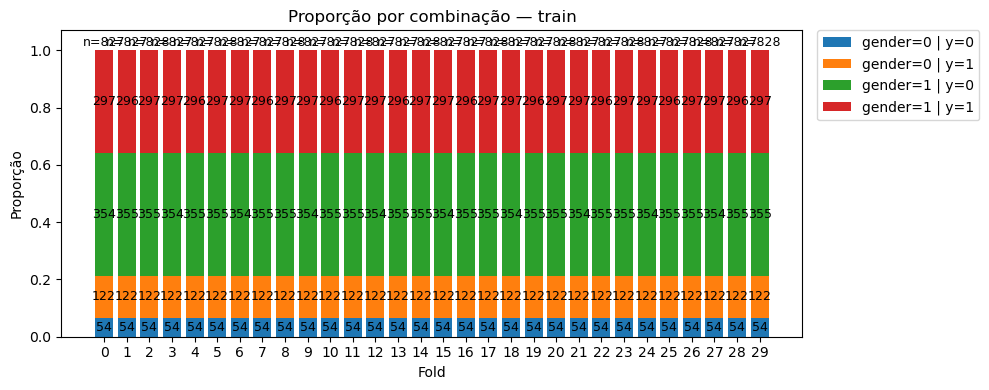

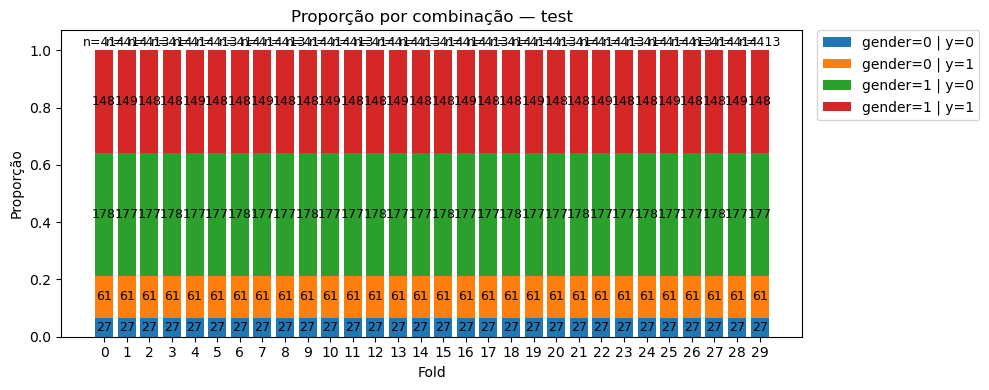

,gender,target,count,pct,total,fold,split,combo
0,0,0,54,0.065296,827,0,train,gender=0 | y=0
1,0,1,122,0.147521,827,0,train,gender=0 | y=1
2,1,0,354,0.428053,827,0,train,gender=1 | y=0
3,1,1,297,0.359129,827,0,train,gender=1 | y=1
4,0,0,27,0.065217,414,0,test,gender=0 | y=0
...,...,...,...,...,...,...,...,...
235,1,1,297,0.358696,828,29,train,gender=1 | y=1
236,0,0,27,0.065375,413,29,test,gender=0 | y=0
237,0,1,61,0.147700,413,29,test,gender=0 | y=1
238,1,0,177,0.428571,413,29,test,gender=1 | y=0


In [16]:
plot_fold_proportions(df, fold_index, target_name=target_name, sen_var=sen_var)

# Baseline

## Logistic class

In [ ]:
common_base = {
    'df':               df,
    'target_name':      target_name,
    'sen_var':          sen_var,
    'fold_index':       fold_index,
    'estimator_class':  LogisticRegression,    # ou DecisionTreeClassifier etc.
    'scaler':           StandardScaler(),
    'fairness_vars':    fairness_vars,
}


In [ ]:
baseline_params_1 = {
    **common_base,
    'exp_id': 'BLRA',
    'estimator_kwargs': {
        'C': 1.0,
        'penalty': 'l2',
        'n_jobs': -1,
        'random_state': global_seed,
    },
    'awareness': True
}

baseline_params_2 = {
    **common_base,
    'exp_id': 'BLRU',
    'estimator_kwargs': {
        'C': 1.0,
        'penalty': 'l2',
        'n_jobs': -1,
        'random_state': global_seed,
    },
    'awareness': False
}

In [ ]:
res_b1 = exp.run_experiment_baseline(**baseline_params_1)

In [ ]:
np.mean([x['disparate_impact'] for x in res_b1])

In [ ]:
res_b1 = exp.run_experiment_baseline(**baseline_params_1)
summary_df, _ = create_execution_level_df(res_b1, all_summary_df)

file_path = output_dir / f"{baseline_params_1["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

In [ ]:
res_b2 = exp.run_experiment_baseline(**baseline_params_2)
summary_df, _ = create_execution_level_df(res_b2, all_summary_df)

file_path = output_dir / f"{baseline_params_2["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

### Memory

In [ ]:
del common_base, baseline_params_1, baseline_params_2, res_b1, res_b2, summary_df
gc.collect()


## Random Forest

In [ ]:
common_base = {
    'df':               df,
    'target_name':      target_name,
    'sen_var':          sen_var,
    'fold_index':       fold_index,
    'estimator_class':  RandomForestClassifier,    
    'fairness_vars':    fairness_vars
}

baseline_params_1 = {
    **common_base,
    'exp_id': 'BRFA',
    'estimator_kwargs': {
        "n_estimators": 200,
         "criterion": "gini",
         "max_depth": 20,
        'random_state': global_seed
    },
    'awareness': True
}

res_b1 = exp.run_experiment_baseline(**baseline_params_1)
summary_df, _ = create_execution_level_df(res_b1, all_summary_df)

file_path = output_dir / f"{baseline_params_1["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

In [ ]:
common_base = {
    'df':               df,
    'target_name':      target_name,
    'sen_var':          sen_var,
    'fold_index':       fold_index,
    'estimator_class':  RandomForestClassifier,    
    'fairness_vars':    fairness_vars
}

baseline_params_1 = {
    **common_base,
    'exp_id': 'BRFU',
    'estimator_kwargs': {
        "n_estimators": 200,
         "criterion": "gini",
         "max_depth": 20,
        'random_state': global_seed
    },
    'awareness': False
}

res_b1 = exp.run_experiment_baseline(**baseline_params_1)
summary_df, _ = create_execution_level_df(res_b1, all_summary_df)

file_path = output_dir / f"{baseline_params_1["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

# Fairness treatment

## Disparate impact Remover

In [ ]:

disparate_impact_params = {
    'df':               df,
    'target_name':      target_name,
    'sen_var':          sen_var,
    'fold_index':       fold_index,
    'exp_id':           'EDL',
    'estimator_class':  LogisticRegression,
    'estimator_kwargs': {
        'C': 1.0,
        'penalty': 'l2',
        'n_jobs': -1,
        'random_state': global_seed
    },
    'awareness': True,
    'preprocessing_class': DisparateImpactRemover(repair_level=0.8),
    'scaler': StandardScaler(),
    'fairness_vars':    fairness_vars
}


In [ ]:
results_dir = exp.run_experiment_preprocessing(**disparate_impact_params)
summary_df, _ = create_execution_level_df(results_dir, all_summary_df)

file_path = output_dir / f"{disparate_impact_params["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

In [ ]:
del disparate_impact_params, results_dir, summary_df
gc.collect()

## Reweighting

In [ ]:
rw_params = {
        'df': df,
        'target_name': target_name,
        'sen_var': sen_var,
        'fold_index': fold_index,
        'exp_id': 'ERW',
        'estimator_class': LogisticRegression,
        'estimator_kwargs': {
            'C': 1.0,
            'penalty': 'l2',
            'max_iter': 1000,
            'n_jobs': -1,
            'random_state': global_seed
        },
        'awareness': True,
        'preprocessing_class': Reweighing(
            unprivileged_groups=fairness_vars['unprivileged_groups'],
            privileged_groups=fairness_vars['privileged_groups']
        ),
        'scaler': StandardScaler(),
        'fairness_vars': fairness_vars
    }

In [ ]:
import importlib
import auxiliar.experiments_pipeline as exp
importlib.reload(exp)

In [ ]:
results_dir = exp.run_experiment_preprocessing(**rw_params)
summary_df, _ = create_execution_level_df(results_dir, all_summary_df)

file_path = output_dir / f"{rw_params["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

## Grid Search Reduction

In [ ]:
common_grid_search = {
    'df':              df,
    'target_name':     target_name,
    'sen_var':         sen_var,
    'fold_index':      fold_index,
    'estimator_class': GridSearchReduction,
    'scaler':          StandardScaler(),
    'seed':            global_seed,
    'fairness_vars':   fairness_vars
}


In [ ]:
grid_search_params_1 = {
    **common_grid_search,
    'exp_id': 'IGLA',
    'estimator_kwargs': {
        'estimator':      LogisticRegression(random_state=42),
        'constraints':    'DemographicParity',
        'constraint_weight': 0.5, 
        'grid_size':      20,
        'grid_limit':     2,
        'prot_attr':      sen_var,
        'drop_prot_attr': False,
        'loss': 'ZeroOne'
    }
}

grid_search_params_2 = {
    **common_grid_search,
    'exp_id': 'IGLU',
    'estimator_kwargs': {
        'estimator':      LogisticRegression(random_state=42),
        'constraints':    'DemographicParity',
        'constraint_weight': 0.5, 
        'grid_size':      20,
        'grid_limit':     2,
        'prot_attr':      sen_var,
        'drop_prot_attr': True,
        'loss': 'ZeroOne'
    }
}

In [ ]:
results_dir = exp.run_experiment(**grid_search_params_1)
summary_df, _ = create_execution_level_df(results_dir, all_summary_df)

file_path = output_dir / f"{grid_search_params_1["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

results_dir = exp.run_experiment(**grid_search_params_2)
summary_df, _ = create_execution_level_df(results_dir, all_summary_df)

file_path = output_dir / f"{grid_search_params_2["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

In [ ]:
del common_grid_search, grid_search_params_1, grid_search_params_2, results_dir, summary_df

## Prejudice Remover

In [ ]:
common_prejudice_remover = {
    'df':              df,
    'target_name':     target_name,
    'sen_var':         sen_var,
    'estimator_class': PrejudiceRemover,
    'scaler':          StandardScaler(),
    'seed':            global_seed,
    'fairness_vars':   fairness_vars
}


In [ ]:
prejudice_remover_params = {
    **common_prejudice_remover,
    'fold_index':      fold_index,
    'exp_id': 'IP',
    'estimator_kwargs': {
        'eta':15,
        'sensitive_attr': sen_var,
        'class_attr': target_name
    }
}

In [ ]:
results_dir = exp.run_experiment(**prejudice_remover_params)
summary_df, _ = create_execution_level_df(results_dir, all_summary_df)

file_path = output_dir / f"{prejudice_remover_params["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

## Adversarial Debiasing

In [ ]:

common_adv = {
    'df':              df,
    'target_name':     target_name,
    'sen_var':         sen_var,
    'scaler':          StandardScaler(),
    'seed':            global_seed,
    'fairness_vars':   fairness_vars,
}

adversarial_params = {
    **common_adv,
    'fold_index': fold_index,
    'exp_id': 'IAD',   # In-processing Adversarial Debiasing
    'estimator_kwargs': {
        'privileged_groups':   [{sen_var: 1}],
        'unprivileged_groups': [{sen_var: 0}],
        'num_epochs': 100,
        'batch_size': 128,
        'classifier_num_hidden_units': 200,
        'adversary_loss_weight': 0.1,
        'debias': True
    },
}

results_dir = exp.run_experiment_adv_debiasing(**adversarial_params)
summary_df, _ = create_execution_level_df(results_dir, all_summary_df)

file_path = output_dir / f"{adversarial_params['exp_id']}.csv"
summary_df.to_csv(file_path, index=False)


## Westerstein fairness

In [17]:
common_wesserstein = {
    'df':              df,
    'target_name':     target_name,
    'sen_var':         sen_var,
    'fold_index':      fold_index,
    'estimator_class': WessersteinFairClassifier,
    'scaler':          StandardScaler(),
    'fairness_vars':   fairness_vars
}


In [ ]:
ws_params = {
    **common_wesserstein,
    "exp_id": "IW",
    "awareness": True,
    "estimator_kwargs": {
        # Optimization params (paper sweep ranges)
        "alpha": 0.5,                  # [0, 0.5] ✓
        "beta": 100,                    # [10^-2, ..., 10^2] ✓
        "lr": 0.1,                    # [10^-4, ..., 10^-1] ✓
        "max_iter": 2000,             # Paper: M = 80,000 
        
        # Wasserstein config
        "distance": "wasserstein-1",
        "solver": "line",
        "delta": 0.005,
        
        # Barycenter config (POT)
        "barycenter": True,
        "bary_every": 100000,          # K > M (só calcula uma vez, em i=0)
        "bary_bins": 50,               # Paper: B = [50, 90]
        "bary_reg": 1e-2,              # Paper: δ = [10^-3, 5×10^-3, 10^-2] ✓
        "bary_max_iter": 1000,         # Paper: M = 1000 POT 
        "bary_n_samples": 200,
        
        # Initialization
        "init_from_lr": True,          # Paper: "θ0 from trained LR" ✓
        
        "fairness_vars": fairness_vars,
        "verbose": True,
        "random_state": global_seed,
    },
}


In [19]:
# np.mean([x['f1'] for x in results_dir])
# np.mean([x['disparate_impact'] for x in results_dir])

In [20]:
results_dir = exp.run_experiment_baseline(**ws_params)
summary_df, _ = create_execution_level_df(results_dir, all_summary_df)

file_path = output_dir / f"{ws_params["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

CV folds:   0%|          | 0/30 [00:00<?, ?fold/s]

Initialized theta from LogisticRegression
Iter 00000 | total=12.483935 | log=0.545605 | wass=0.244223 | grad_norm=0.093026 | step=0.009303 | theta_norm=2.9805
Iter 00100 | total=8.509386 | log=0.551591 | wass=0.164672 | grad_norm=0.035707 | step=0.003571 | theta_norm=2.8962
Iter 00200 | total=5.482149 | log=0.561038 | wass=0.104033 | grad_norm=0.029156 | step=0.002916 | theta_norm=2.8884
Iter 00300 | total=3.130776 | log=0.570965 | wass=0.056906 | grad_norm=0.020942 | step=0.002094 | theta_norm=2.9112
Iter 00400 | total=2.111265 | log=0.575906 | wass=0.036466 | grad_norm=0.011389 | step=0.001139 | theta_norm=2.9494
Iter 00500 | total=1.838582 | log=0.576714 | wass=0.031005 | grad_norm=0.007420 | step=0.000742 | theta_norm=2.9843
Iter 00600 | total=1.712066 | log=0.577277 | wass=0.028469 | grad_norm=0.003975 | step=0.000398 | theta_norm=3.0065
Iter 00700 | total=1.669321 | log=0.577458 | wass=0.027612 | grad_norm=0.002654 | step=0.000265 | theta_norm=3.0200
Iter 00800 | total=1.664750 |

c:\Users\gabri\anaconda3\envs\fairness-research\Lib\site-packages\pycol_complexity\complexity.py:2411: RuntimeWarning: invalid value encountered in divide
  n_d = numer/denom


Initialized theta from LogisticRegression
Iter 00000 | total=12.482822 | log=0.543289 | wass=0.244224 | grad_norm=0.091385 | step=0.009138 | theta_norm=2.9441
Iter 00100 | total=8.901688 | log=0.548107 | wass=0.172553 | grad_norm=0.034435 | step=0.003444 | theta_norm=2.8484
Iter 00200 | total=6.049849 | log=0.555958 | wass=0.115437 | grad_norm=0.029586 | step=0.002959 | theta_norm=2.8186
Iter 00300 | total=3.697894 | log=0.564742 | wass=0.068310 | grad_norm=0.023689 | step=0.002369 | theta_norm=2.8268
Iter 00400 | total=2.138002 | log=0.571881 | wass=0.037041 | grad_norm=0.015813 | step=0.001581 | theta_norm=2.8439
Iter 00500 | total=1.651794 | log=0.574388 | wass=0.027292 | grad_norm=0.006202 | step=0.000620 | theta_norm=2.8561
Iter 00600 | total=1.572403 | log=0.574613 | wass=0.025702 | grad_norm=0.004250 | step=0.000425 | theta_norm=2.8650
Iter 00700 | total=1.544604 | log=0.574409 | wass=0.025148 | grad_norm=0.004008 | step=0.000401 | theta_norm=2.8724
Iter 00800 | total=1.520795 |

c:\Users\gabri\anaconda3\envs\fairness-research\Lib\site-packages\pycol_complexity\complexity.py:2411: RuntimeWarning: invalid value encountered in divide
  n_d = numer/denom


...

Initialized theta from LogisticRegression
Iter 00000 | total=12.502900 | log=0.523952 | wass=0.244818 | grad_norm=0.094980 | step=0.009498 | theta_norm=3.3825
Iter 00100 | total=9.161135 | log=0.528663 | wass=0.177936 | grad_norm=0.033185 | step=0.003318 | theta_norm=3.3107
Iter 00200 | total=6.526600 | log=0.536131 | wass=0.125171 | grad_norm=0.028306 | step=0.002831 | theta_norm=3.2939
Iter 00300 | total=4.489261 | log=0.543860 | wass=0.084347 | grad_norm=0.020924 | step=0.002092 | theta_norm=3.3000
Iter 00400 | total=3.303044 | log=0.549732 | wass=0.060564 | grad_norm=0.013703 | step=0.001370 | theta_norm=3.3118
Iter 00500 | total=2.646461 | log=0.553559 | wass=0.047394 | grad_norm=0.009764 | step=0.000976 | theta_norm=3.3287
Iter 00600 | total=2.282370 | log=0.555661 | wass=0.040091 | grad_norm=0.006928 | step=0.000693 | theta_norm=3.3446
Iter 00700 | total=2.108823 | log=0.556592 | wass=0.036611 | grad_norm=0.004778 | step=0.000478 | theta_norm=3.3599
Iter 00800 | total=2.045632 |

c:\Users\gabri\anaconda3\envs\fairness-research\Lib\site-packages\pycol_complexity\complexity.py:2411: RuntimeWarning: invalid value encountered in divide
  n_d = numer/denom


Initialized theta from LogisticRegression
Iter 00000 | total=12.512632 | log=0.507390 | wass=0.245179 | grad_norm=0.087669 | step=0.008767 | theta_norm=3.6034
Iter 00100 | total=9.451334 | log=0.511502 | wass=0.183912 | grad_norm=0.032064 | step=0.003206 | theta_norm=3.5383
Iter 00200 | total=6.973802 | log=0.518326 | wass=0.134293 | grad_norm=0.027752 | step=0.002775 | theta_norm=3.5209
Iter 00300 | total=4.939996 | log=0.525939 | wass=0.093541 | grad_norm=0.022074 | step=0.002207 | theta_norm=3.5269
Iter 00400 | total=3.442238 | log=0.533091 | wass=0.063514 | grad_norm=0.017537 | step=0.001754 | theta_norm=3.5399
Iter 00500 | total=2.413365 | log=0.538629 | wass=0.042881 | grad_norm=0.011711 | step=0.001171 | theta_norm=3.5586
Iter 00600 | total=2.063858 | log=0.540543 | wass=0.035872 | grad_norm=0.005809 | step=0.000581 | theta_norm=3.5729
Iter 00700 | total=1.945167 | log=0.541267 | wass=0.033491 | grad_norm=0.003778 | step=0.000378 | theta_norm=3.5823
Iter 00800 | total=1.890684 |

c:\Users\gabri\anaconda3\envs\fairness-research\Lib\site-packages\pycol_complexity\complexity.py:2411: RuntimeWarning: invalid value encountered in divide
  n_d = numer/denom


Initialized theta from LogisticRegression
Iter 00000 | total=12.549361 | log=0.531377 | wass=0.245673 | grad_norm=0.095510 | step=0.009551 | theta_norm=3.1860
Iter 00100 | total=8.845197 | log=0.536888 | wass=0.171535 | grad_norm=0.034548 | step=0.003455 | theta_norm=3.1021
Iter 00200 | total=6.020545 | log=0.545313 | wass=0.114958 | grad_norm=0.027960 | step=0.002796 | theta_norm=3.0866
Iter 00300 | total=4.043330 | log=0.553045 | wass=0.075336 | grad_norm=0.021202 | step=0.002120 | theta_norm=3.0949
Iter 00400 | total=2.797566 | log=0.558800 | wass=0.050363 | grad_norm=0.014851 | step=0.001485 | theta_norm=3.1196
Iter 00500 | total=2.119685 | log=0.562420 | wass=0.036769 | grad_norm=0.010463 | step=0.001046 | theta_norm=3.1523
Iter 00600 | total=1.813350 | log=0.563762 | wass=0.030629 | grad_norm=0.007238 | step=0.000724 | theta_norm=3.1836
Iter 00700 | total=1.709022 | log=0.564082 | wass=0.028540 | grad_norm=0.004710 | step=0.000471 | theta_norm=3.2050
Iter 00800 | total=1.666547 |

In [ ]:
gc.collect()

40557

: 

## Fair GBM

In [ ]:
common_fairgbm = {
    'df':              df,
    'target_name':     target_name,
    'sen_var':         sen_var,
    'fold_index':      fold_index,
    'estimator_class': FairGBMCustom,
    'fairness_vars':fairness_vars
}


In [ ]:
fairgbm_params = {
    **common_fairgbm,
    'exp_id': 'IFG',
    'awareness': True,  # inclui a variável sensível no X
    'estimator_kwargs': {
        'fairness_vars':fairness_vars,
        'n_estimators':100,
        'max_depth':3,
        "random_state": global_seed
    }
}

In [ ]:
results_dir = exp.run_experiment_baseline(**fairgbm_params)

In [ ]:
results_dir = exp.run_experiment_baseline(**fairgbm_params)
summary_df, _ = create_execution_level_df(results_dir, all_summary_df)

file_path = output_dir / f"{fairgbm_params["exp_id"]}.csv"
summary_df.to_csv(file_path, index=False)

# Export

In [ ]:
#all_summary_df.to_csv(f"results/{dataset_code}_executions_2.csv", index=False)